## AQ2: How well can our learned transition and reward functions predict user behaviour compared to methods that do not consider state and/or action?

This notebook evaluates the predictive performance of the learned MOMDP dynamics models (transition and reward functions) by comparing our full state-action MOMDP model against different simpler approaches for the following prediction tasks:
- **Reward prediction**: Deterministic reward functions, which are used for policy iteration
- **Outcome prediction**: Stochastic outcomes, used for simulation.
- **Completion prediction**: Challenge completion probabilities, used for simulation.
- **Transition prediction**: Transition probabilities, used for simulation and policy iteration.

Results are analyzed using leave-one-out cross-validation across users and Bayesian hypothesis testing. These results were used to answer AQ2 in Chapter 5 of the thesis, and to create the accompanying figures.

**Author:** Shirley Li  
**Date:** July 2026

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import pyperclip

sys.path.append(os.path.abspath('..'))
import utils.utils as utils
import utils.mdp_utils as mdp_utils
import utils.process_data as dp
import utils.bayesian_analysis as ba
import config

palette = sns.color_palette("muted")
sns.set_palette(palette)
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

%load_ext autoreload
%autoreload 2

### Load data and process samples

In [2]:
NUM_STATES, NUM_ACTIONS, NUM_OBJECTIVES = config.NUM_STATES, config.NUM_ACTIONS, config.NUM_OBJECTIVES
action_col, reward_cols = config.action_col, config.reward_cols

state_to_idx, idx_to_state = utils.build_state_space(config.NUM_VALS_PER_FEATURE)

data_folder = '..\\..\\data\\'
results_folder = '..\\..\\results\\'

# Load and prepare data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples_corrected_full.csv'))

actions_clustered, _, _ = dp.cluster_actions(action_data, config.cluster_vars, num_clusters=config.NUM_CLUSTERS)

df, agency_df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, config.state_features, config.NUM_VALS_PER_FEATURE, action_col, config.cluster_col)

# stochastic outcomes and their number of possible values
stochastic_outcomes = {"likedness": 11, "usefulness": 7, "difficulty": 11, "PAY_next": 7}

### Evaluation Function

The `evaluate_dynamics` function computes predictions for each observation in the test set using different model variants and computes likelihoods and errors. 

In [ ]:
def evaluate_dynamics(test_df, P_comp, R, P, R_action_only, R_global, P_comp_action_only, p_comp_overall, R_outcomes, R_outcomes_action_only, R_probs_diff_global):
    data_list = []
    for t in range(len(test_df)):
        user_row = {"t": t}
        # True values
        s_t = test_df.iloc[t]['s_idx']
        a_t = test_df.iloc[t][config.action_col]
        challenge_id = test_df.iloc[t]['challenge_id']
        s_t_next = test_df.iloc[t]['sp_idx']
        r_t = test_df.iloc[t][config.reward_cols].values
        completed = test_df.iloc[t]['completed']

        # Reward predictions
        r_pred = R[s_t, a_t]
        r_pred_action_only = R_action_only[a_t]
        r_pred_global = R_global
        
        for i, obj in enumerate(config.reward_cols):
            user_row[f'{obj}_l1_error'] = np.abs(r_t[i] - r_pred[i])
            user_row[f'{obj}_l1_error_action_only'] = np.abs(r_t[i] - r_pred_action_only[i])
            user_row[f'{obj}_l1_error_global'] = np.abs(r_t[i] - r_pred_global[i])

        # Next state likelihood
        P_s_t_next = P[s_t, a_t, s_t_next]
        user_row['next_state_likelihood'] = P_s_t_next
        user_row['equal_state'] = (s_t_next == s_t)
        user_row['s_idx'] = s_t
        user_row['s_idx_next'] = s_t_next

        # Completion likelihood
        P_comp_pred = P_comp[s_t, a_t]
        P_comp_pred_action_only = P_comp_action_only[a_t]
        user_row['completion_likelihood'] = P_comp_pred if completed else (1 - P_comp_pred)
        user_row['completion_likelihood_action_only'] = P_comp_pred_action_only if completed else (1 - P_comp_pred_action_only)
        user_row['completion_likelihood_overall'] = p_comp_overall if completed else (1 - p_comp_overall)
        user_row['completed'] = completed

        if completed:
            for outcome in stochastic_outcomes:
                outcome_value_t = test_df.iloc[t][outcome]                                       
                outcome_value_t = outcome_value_t - 1  # for indexing 
                if pd.isna(outcome_value_t):
                    continue  # Skip if outcome value is missing
                R_outcome = R_outcomes[outcome]
                user_row[f'{outcome}_likelihood'] = R_outcome[s_t, a_t, int(outcome_value_t)]

                R_outcome_action_only = R_outcomes_action_only[outcome]
                outcome_likelihood_action_only = R_outcome_action_only[a_t, int(outcome_value_t)]
                user_row[f'{outcome}_likelihood_action_only'] = outcome_likelihood_action_only

                R_outcome_global = R_probs_diff_global[outcome]
                user_row[f'{outcome}_likelihood_global'] = R_outcome_global[int(outcome_value_t)]
        data_list.append(user_row)
        
    return pd.DataFrame(data_list)

### Run evaluation

Perform leave-one-user-out cross-validation: for each user, train all models on data from all other users and evaluate on the held-out user's test set. 

In [ ]:
all_users = df['user_id'].unique()
print("Number of users:", len(all_users))

lam = 1

all_user_results = []
for test_user in all_users:

    train_df = df[df['user_id'] != test_user]
    test_df = df[df['user_id'] == test_user]
    filtered_train_df = train_df[~(train_df['completed'] == 1 & (train_df['difficulty'] == 0))]
    
    P_comp = mdp_utils.compute_completion_probabilities(train_df, NUM_STATES, NUM_ACTIONS, action_col, prior='action_only')
    R = mdp_utils.compute_rewards(filtered_train_df, NUM_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, action_col, mapping)
    R_action_only = mdp_utils.compute_avg_rewards(filtered_train_df, NUM_ACTIONS, action_col, reward_cols)
    R_global = mdp_utils.compute_rewards_global(filtered_train_df, reward_cols)
    
    P = mdp_utils.compute_transition_probabilities(train_df, NUM_STATES, NUM_ACTIONS, action_col)
    
    P_comp_action_only = mdp_utils.compute_completion_probabilities_action_only(train_df, NUM_ACTIONS, action_col)
    p_comp_overall = train_df['completed'].mean()

    R_outcomes = {o: mdp_utils.compute_reward_probabilities(filtered_train_df, o, NUM_STATES, NUM_ACTIONS, action_col, lam=lam) for o in stochastic_outcomes}

    R_outcomes_action_only = {o: mdp_utils.compute_reward_probabilities_action_only(filtered_train_df, o, NUM_ACTIONS, action_col, lam=0) for o in stochastic_outcomes}
        
    R_probs_diff_global = {o: mdp_utils.compute_reward_probabilities_global(filtered_train_df, o) for o in stochastic_outcomes}
    
    result_df = evaluate_dynamics(test_df, P_comp, R, P, R_action_only, R_global, P_comp_action_only, p_comp_overall, 
                                  R_outcomes, R_outcomes_action_only, R_probs_diff_global)
    result_df['user_id'] = test_user
    all_user_results.append(result_df)
    
combined_results = pd.concat(all_user_results, ignore_index=True)

Number of users: 314


### Reward function evaluation
To evaluate our learned reward function, we compare it against using 1) only the action, and 2) the global mean to predict the reward.

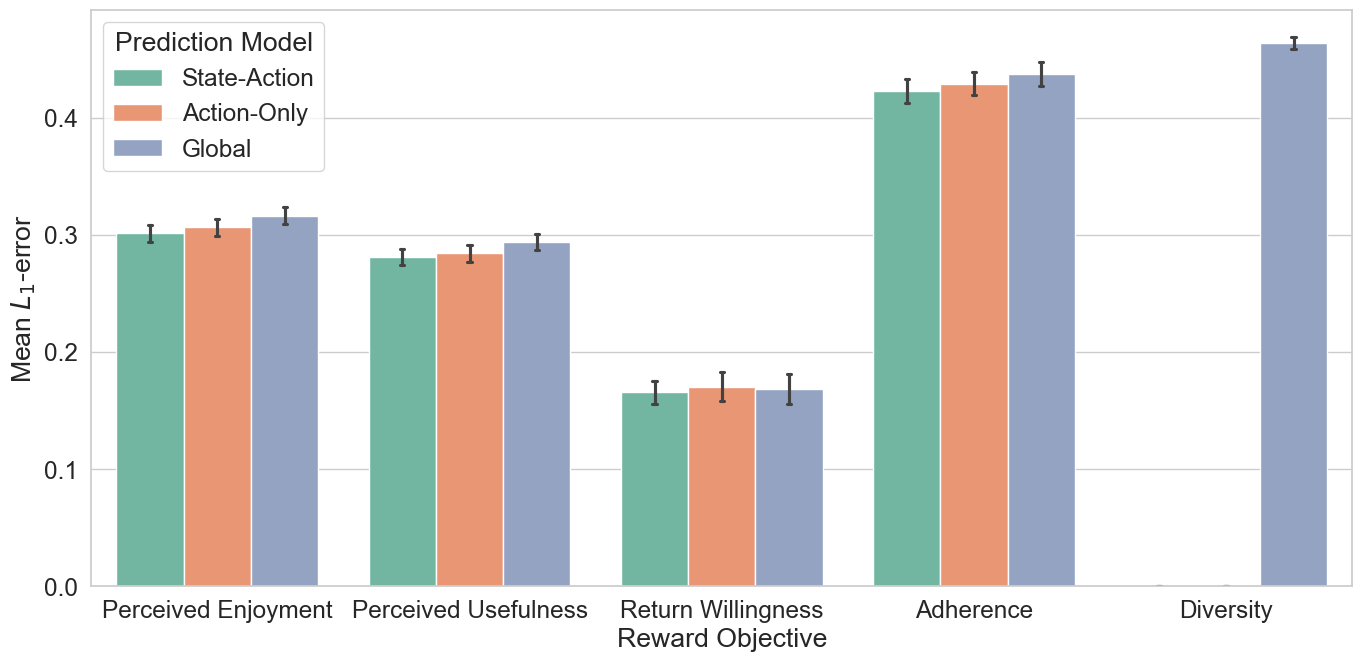

In [55]:
plot_records = []
for obj, obj_name in zip(reward_cols, config.reward_names):
    # if obj == "r_diversity":
    #     continue
    state_action = combined_results.groupby('user_id')[f'{obj}_l1_error'].mean()
    for err in state_action:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'State-Action'})
    
    action_only = combined_results.groupby('user_id')[f'{obj}_l1_error_action_only'].mean()
    for err in action_only:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'Action-Only'})

    global_errors = combined_results.groupby('user_id')[f'{obj}_l1_error_global'].mean()
    for err in global_errors:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'Global'})

viz_df = pd.DataFrame(plot_records)

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.6)
ax = sns.barplot(
    data=viz_df, 
    x='Objective', 
    y='L1 Error', 
    hue='Model', 
    palette="Set2",
    capsize=.05,
    errorbar=('ci', 95)
)

plt.ylabel('Mean $L_1$-error')
plt.xlabel('Reward Objective')
plt.legend(title='Prediction Model', frameon=True)

plt.tight_layout()
plt.savefig(results_folder + "figures/reward_model_comparison.svg", bbox_inches='tight')
plt.show()

#### Bayesian analysis
Test whether state-action improves over action-only

In [7]:
results = []
for obj, obj_name in zip(reward_cols, config.reward_names):
    if obj == "r_diversity":
        continue  # Skip diversity for this analysis, since it is deterministic
    combined_results[f'{obj}_improvement'] = combined_results[f'{obj}_l1_error_action_only'] - combined_results[f'{obj}_l1_error']
    user_diffs = combined_results.groupby('user_id')[f'{obj}_improvement'].mean().values
    print(f"Testing {obj_name}")
    result = ba.paired_t_test(user_diffs, name=obj_name)
    results.append(result)

results_df_rewards = pd.concat(results, ignore_index=True)

Testing Perceived Enjoyment
Posterior probability improvement > 0: 1.0000
Testing Perceived Usefulness
Posterior probability improvement > 0: 0.9958
Testing Return Willingness
Posterior probability improvement > 0: 0.9505
Testing Adherence
Posterior probability improvement > 0: 0.9998


In [8]:
pyperclip.copy(ba.to_latex_body(results_df_rewards))
results_df_rewards

,objective,mean,std,hdi_low,hdi_high,post_prob,small,medium,large,mean_hdi,interpretation
0,Perceived Enjoyment,0.005471,0.001397,0.002809,0.008273,1.00000,0.98725,0.74825,0.17525,"\makecell{$0.005$\\$[0.003,\,0.008]$}",Virtually certain
1,Perceived Usefulness,0.003677,0.001445,0.000817,0.006403,0.99575,0.81750,0.24900,0.01125,"\makecell{$0.004$\\$[0.001,\,0.006]$}",Very strong bet
2,Return Willingness,0.004492,0.002807,-0.000830,0.010038,0.95050,0.43425,0.02475,0.00000,"\makecell{$0.004$\\$[-0.001,\,0.010]$}",\makecell{Good bet\\too good to disregard}
3,Adherence,0.006254,0.001824,0.002661,0.009685,0.99975,0.96250,0.56200,0.07925,"\makecell{$0.006$\\$[0.003,\,0.010]$}",Nearing certainty


Test whether state-action improves over global

In [ ]:
results_global = []
for obj, obj_name in zip(reward_cols, config.reward_names):
    if obj == "r_diversity":
        continue  # Skip diversity for this analysis, since it is deterministic
    combined_results[f'{obj}_improvement_over_global'] = combined_results[f'{obj}_l1_error_global'] - combined_results[f'{obj}_l1_error']
    user_diffs = combined_results.groupby('user_id')[f'{obj}_improvement_over_global'].mean().values
    print(f"Testing {obj_name}")
    result = ba.paired_t_test(user_diffs, name=obj_name)
    results_global.append(result)

results_global_df_rewards = pd.concat(results_global, ignore_index=True)

In [58]:
pyperclip.copy(ba.to_latex_body(results_global_df_rewards))
results_global_df_rewards

,objective,mean,std,hdi_low,hdi_high,post_prob,small,medium,large,mean_hdi,interpretation
0,Perceived Enjoyment,0.015087,0.001789,0.011602,0.018508,1.00000,1.00000,1.0000,0.99825,"\makecell{$0.015$\\$[0.012,\,0.019]$}",Virtually certain
1,Perceived Usefulness,0.013202,0.001617,0.010076,0.016302,1.00000,1.00000,1.0000,0.99900,"\makecell{$0.013$\\$[0.010,\,0.016]$}",Virtually certain
2,Return Willingness,0.002795,0.002873,-0.002495,0.008506,0.82775,0.22075,0.0050,0.00000,"\makecell{$0.003$\\$[-0.002,\,0.009]$}",\makecell{Only a casual\\bet}
3,Adherence,0.014931,0.002216,0.010766,0.019413,1.00000,1.00000,0.9995,0.93225,"\makecell{$0.015$\\$[0.011,\,0.019]$}",Virtually certain


Test whether action-only improves over global

In [ ]:
results_action_global = []
for obj, obj_name in zip(reward_cols, config.reward_names):
    if obj == "r_diversity":
        continue  # Skip diversity for this analysis, since it is deterministic
    combined_results[f'{obj}_improvement_action_over_global'] = combined_results[f'{obj}_l1_error_global'] - combined_results[f'{obj}_l1_error_action_only']
    user_diffs = combined_results.groupby('user_id')[f'{obj}_improvement_action_over_global'].mean().values
    print(f"Testing {obj_name}")
    result = ba.paired_t_test(user_diffs, name=obj_name)
    results_action_global.append(result)

results_action_global_df_rewards = pd.concat(results_action_global, ignore_index=True)

In [59]:
pyperclip.copy(ba.to_latex_body(results_action_global_df_rewards))
results_action_global_df_rewards

,objective,mean,std,hdi_low,hdi_high,post_prob,small,medium,large,mean_hdi,interpretation
0,Perceived Enjoyment,0.010313,0.001207,0.007904,0.012660,1.0,1.0,1.0,0.99950,"\makecell{$0.010$\\$[0.008,\,0.013]$}",Virtually certain
1,Perceived Usefulness,0.009873,0.000979,0.007887,0.011698,1.0,1.0,1.0,1.00000,"\makecell{$0.010$\\$[0.008,\,0.012]$}",Virtually certain
2,Return Willingness,-0.001792,0.000151,-0.002091,-0.001495,0.0,1.0,1.0,1.00000,"\makecell{$-0.002$\\$[-0.002,\,-0.001]$}",Virtually certain against
3,Adherence,0.008579,0.001223,0.006067,0.010828,1.0,1.0,1.0,0.96625,"\makecell{$0.009$\\$[0.006,\,0.011]$}",Virtually certain


### Stochastic Outcome Prediction

Evaluates the learned conditional outcome distributions P(reward_value | state, action). Compares the state-action model against action-only and global baselines for predicting outcomes.

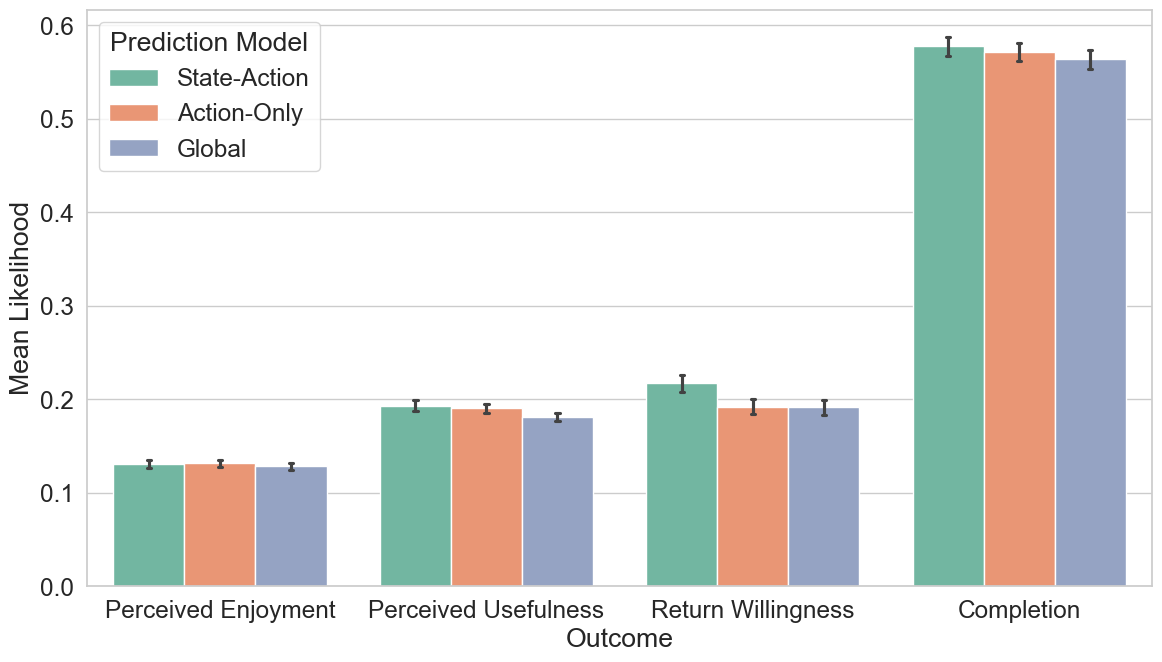

In [ ]:
# plot mean likelihoods of outcomes
outcomes_to_test = {"likedness": "Perceived Enjoyment", "usefulness": "Perceived Usefulness", "PAY_next": "Return Willingness"}

plot_records = []
combined_results_completed = combined_results[combined_results['completed'] == 1]
for obj, obj_name in outcomes_to_test.items():
    state_action = combined_results_completed.groupby('user_id')[f'{obj}_likelihood'].mean()
    for prob in state_action:
        plot_records.append({'Outcome': obj_name, 'Likelihood': prob, 'Model': 'State-Action'})
    
    action_only = combined_results_completed.groupby('user_id')[f'{obj}_likelihood_action_only'].mean()
    for prob in action_only:
        plot_records.append({'Outcome': obj_name, 'Likelihood': prob, 'Model': 'Action-Only'})

    global_likelihoods = combined_results_completed.groupby('user_id')[f'{obj}_likelihood_global'].mean()
    for prob in global_likelihoods:
        plot_records.append({'Outcome': obj_name, 'Likelihood': prob, 'Model': 'Global'})

model_map = {
    'completion_likelihood': 'State-Action',
    'completion_likelihood_action_only': 'Action-Only',
    'completion_likelihood_overall': 'Global'
}

for col, model_name in model_map.items():
    for _, row in combined_results.groupby('user_id').mean().iterrows():
        plot_records.append({
            'Model': model_name,
            'Likelihood': row[col],
            'Completed': 'Completed' if row['completed'] == 1 else 'Not Completed',
            'Outcome': 'Completion'
        })
        

viz_df = pd.DataFrame(plot_records)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.6)

ax = sns.barplot(
    data=viz_df, 
    x='Outcome', 
    y='Likelihood', 
    hue='Model', 
    palette='Set2',
    # whis=[0, 100]
    capsize=.05,
    errorbar=('ci', 95)
)

# plt.title('Predictive Performance: State-Action vs. Action-Only Reward Models', fontsize=14)
plt.ylabel('Mean Likelihood')
plt.xlabel('Outcome')
plt.legend(title='Prediction Model', frameon=True)

plt.tight_layout()
plt.savefig(results_folder + "figures/outcome_model_comparison.svg", bbox_inches='tight')
plt.show()

#### Bayesian analysis
State-action vs. action-only

In [13]:
results = []
for outcome, outcome_name in outcomes_to_test.items():
    combined_results_completed[f'{outcome}_improvement'] = combined_results_completed[f'{outcome}_likelihood'] - combined_results_completed[f'{outcome}_likelihood_action_only']
    user_diffs = combined_results_completed.groupby('user_id')[f'{outcome}_improvement'].mean().values
    print(f"Testing {outcome_name}")
    result = ba.paired_t_test(user_diffs, name=outcome_name)
    results.append(result)

print("Testing Challenge Completion")
combined_results['completion_likelihood_diff'] = combined_results['completion_likelihood'] - combined_results['completion_likelihood_action_only']
user_diffs = combined_results.groupby('user_id')['completion_likelihood_diff'].mean().values
row = ba.paired_t_test(user_diffs, name="Completion")
results.append(row)

results_df = pd.concat(results, ignore_index=True)

Testing Perceived Enjoyment
Posterior probability improvement > 0: 0.3947
Testing Perceived Usefulness
Posterior probability improvement > 0: 0.9565
Testing Return Willingness
Posterior probability improvement > 0: 1.0000
Testing Challenge Completion
Posterior probability improvement > 0: 1.0000


In [14]:
pyperclip.copy(ba.to_latex_body(results_df))
results_df

,objective,mean,std,hdi_low,hdi_high,post_prob,small,medium,large,mean_hdi,interpretation
0,Perceived Enjoyment,-0.000333,0.001178,-0.002534,0.001955,0.39475,0.09400,0.00100,0.00000,"\makecell{$-0.000$\\$[-0.003,\,0.002]$}",\makecell{Not worth\\betting against}
1,Perceived Usefulness,0.002565,0.001530,-0.000402,0.005594,0.95650,0.51975,0.05875,0.00025,"\makecell{$0.003$\\$[-0.000,\,0.006]$}",\makecell{Good bet\\too good to disregard}
2,Return Willingness,0.023543,0.002290,0.019105,0.027998,1.00000,1.00000,1.00000,1.00000,"\makecell{$0.024$\\$[0.019,\,0.028]$}",Virtually certain
3,Completion,0.006125,0.001761,0.002854,0.009645,1.00000,0.96575,0.57350,0.07925,"\makecell{$0.006$\\$[0.003,\,0.010]$}",Virtually certain


State-action vs. global

In [15]:
results = []
for outcome, outcome_name in outcomes_to_test.items():
    combined_results_completed[f'{outcome}_improvement_over_global'] = combined_results_completed[f'{outcome}_likelihood'] - combined_results_completed[f'{outcome}_likelihood_global']
    user_diffs = combined_results_completed.groupby('user_id')[f'{outcome}_improvement_over_global'].mean().values
    print(f"Testing {outcome_name}")
    result = ba.paired_t_test(user_diffs, name=outcome_name)
    results.append(result)

print("Testing Challenge Completion")
combined_results['completion_likelihood_diff_global'] = combined_results['completion_likelihood'] - combined_results['completion_likelihood_overall']
user_diffs = combined_results.groupby('user_id')['completion_likelihood_diff_global'].mean().values
row = ba.paired_t_test(user_diffs, name="Completion")
results.append(row)

results_df_global_outcomes = pd.concat(results, ignore_index=True)

Testing Perceived Enjoyment
Posterior probability improvement > 0: 0.9808
Testing Perceived Usefulness
Posterior probability improvement > 0: 1.0000
Testing Return Willingness
Posterior probability improvement > 0: 1.0000
Testing Challenge Completion
Posterior probability improvement > 0: 1.0000


In [16]:
pyperclip.copy(ba.to_latex_body(results_df_global_outcomes))
results_df_global_outcomes

,objective,mean,std,hdi_low,hdi_high,post_prob,small,medium,large,mean_hdi,interpretation
0,Perceived Enjoyment,0.002638,0.001294,0.000162,0.005191,0.98075,0.644,0.09700,0.00175,"\makecell{$0.003$\\$[0.000,\,0.005]$}",\makecell{Good bet\\too good to disregard}
1,Perceived Usefulness,0.011303,0.001705,0.008091,0.014699,1.00000,1.000,0.99975,0.96550,"\makecell{$0.011$\\$[0.008,\,0.015]$}",Virtually certain
2,Return Willingness,0.024005,0.002282,0.019913,0.028870,1.00000,1.000,1.00000,1.00000,"\makecell{$0.024$\\$[0.020,\,0.029]$}",Virtually certain
3,Completion,0.014744,0.002196,0.010558,0.019202,1.00000,1.000,0.99850,0.93675,"\makecell{$0.015$\\$[0.011,\,0.019]$}",Virtually certain


Action-only vs. global

In [17]:
results = []
for outcome, outcome_name in outcomes_to_test.items():
    combined_results_completed[f'{outcome}_improvement_action_over_global'] = combined_results_completed[f'{outcome}_likelihood_action_only'] - combined_results_completed[f'{outcome}_likelihood_global']
    user_diffs = combined_results_completed.groupby('user_id')[f'{outcome}_improvement_action_over_global'].mean().values
    print(f"Testing {outcome_name}")
    result = ba.paired_t_test(user_diffs, name=outcome_name)
    results.append(result)

print("Testing Challenge Completion")
combined_results['completion_likelihood_diff_action_global'] = combined_results['completion_likelihood_action_only'] - combined_results['completion_likelihood_overall']
user_diffs = combined_results.groupby('user_id')['completion_likelihood_diff_action_global'].mean().values
row = ba.paired_t_test(user_diffs, name="Completion")
results.append(row)

results_df_action_global = pd.concat(results, ignore_index=True)

Testing Perceived Enjoyment
Posterior probability improvement > 0: 1.0000
Testing Perceived Usefulness
Posterior probability improvement > 0: 1.0000
Testing Return Willingness
Posterior probability improvement > 0: 0.9970
Testing Challenge Completion
Posterior probability improvement > 0: 1.0000


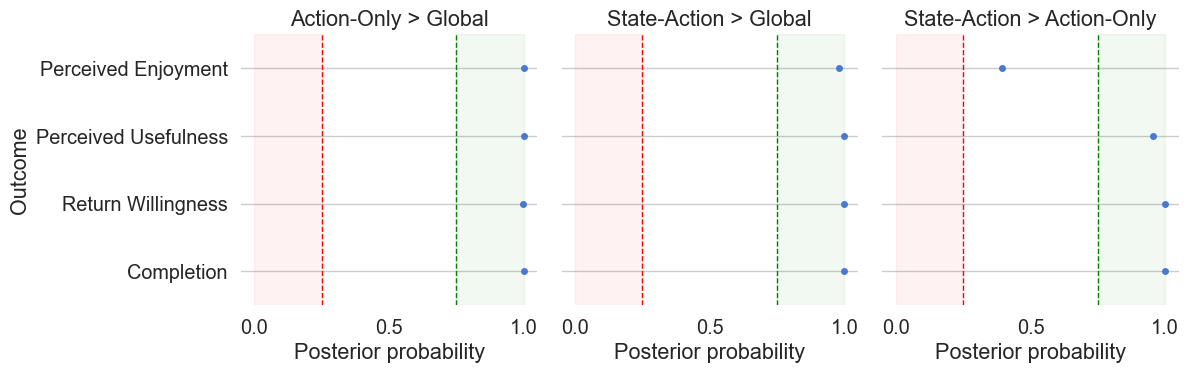

In [33]:
df1 = results_df_action_global.copy()
df2 = results_df_global_outcomes.copy()
df3 = results_df.copy()

df1['Comparison'] = 'Action-Only > Global'
df2['Comparison'] = 'State-Action > Global'
df3['Comparison'] = 'State-Action > Action-Only'

df = pd.concat([df1, df2, df3], ignore_index=True)

sns.set_context("notebook", font_scale=1.3)
ba.plot_post_prob(df, num_comparisons=3, y_label="Outcome", save_path=results_folder + "figures/outcome_comparison_bayesian.svg")

### User State Transition Dynamics

Evaluates the learned state transition probabilities P(s' | s, a). Tests whether the state-action model better predicts the next state than simpler baselines:
- **Stay-in-State Baseline**: Assumes user stays in the same state
- **Uniform Baseline**: Assigns equal probability to all states

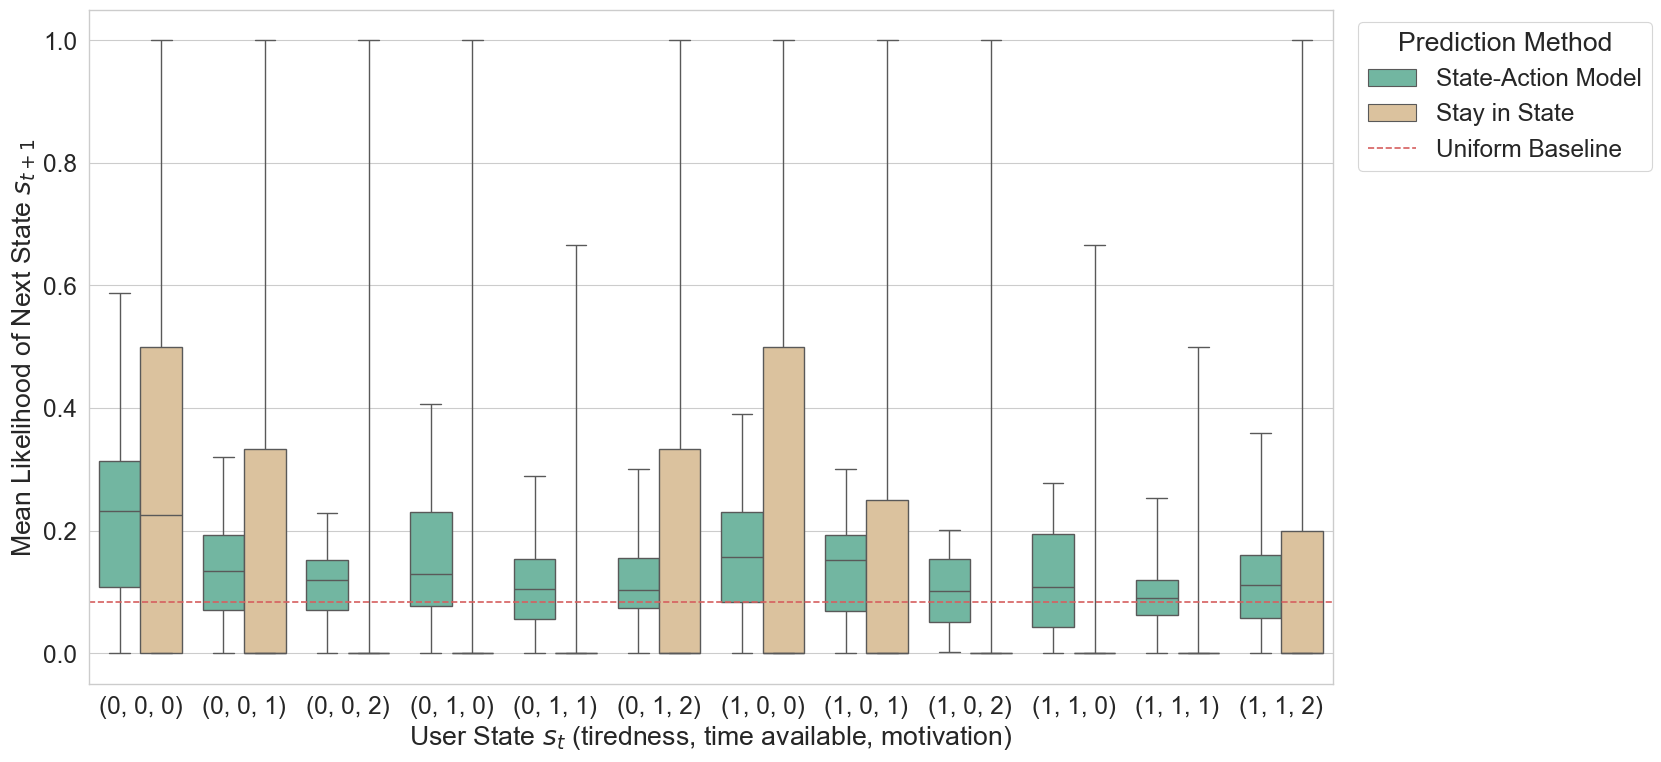

In [ ]:
uniform_prob = 1.0 / NUM_STATES

plot_records = []
model_map = {
    "next_state_likelihood": "State-Action Model",
    "equal_state": "Stay in State",
}

plot_data = (
    combined_results
    .groupby(["s_idx", "user_id"])[list(model_map.keys())]
    .mean()
    .reset_index()
    .melt(id_vars=["s_idx", "user_id"], var_name="Model", value_name="Likelihood")
)

plot_data["State"] = plot_data["s_idx"].apply(lambda x: str(idx_to_state[x]))
plot_data["Model"] = plot_data["Model"].map(model_map)

plt.figure(figsize=(17, 8))
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=2)

palette = sns.color_palette("Set2")
palette = [palette[0], palette[6]]  # Select specific colors for the models

ax = sns.boxplot(
    data=plot_data, 
    x='State', 
    y='Likelihood', 
    hue='Model', 
    palette=palette,
    whis=[0, 100],
)


# plt.title('Next State Likelihood by User State', fontsize=16, pad=20)
plt.ylabel('Mean Likelihood of Next State $s_{t+1}$')
plt.xlabel('User State $s_t$ (tiredness, time available, motivation)')

plt.axhline(uniform_prob, color=sns.color_palette("muted")[3], linestyle='--', alpha=1, label='Uniform Baseline')
# plt.xticks(rotation=45, ha='right')

plt.legend(title='Prediction Method', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.savefig(results_folder + "figures/transition_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

#### Bayesian analysis
State-action vs. stay-in-state

In [20]:
combined_results['next_state_improvement'] = combined_results['next_state_likelihood'] - combined_results['equal_state']
results_transition = []
for state_idx in range(NUM_STATES):
    state_diffs = combined_results[combined_results['s_idx'] == state_idx].groupby('user_id')['next_state_improvement'].mean().values
    print(f"\nState {state_idx} {idx_to_state[state_idx]}:")
    result = ba.paired_t_test(state_diffs, name=idx_to_state[state_idx])
    results_transition.append(result)
results_transition_df = pd.concat(results_transition, ignore_index=True)


State 0 (0, 0, 0):
Posterior probability improvement > 0: 0.0000

State 1 (0, 0, 1):


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Posterior probability improvement > 0: 0.4753

State 2 (0, 0, 2):
Posterior probability improvement > 0: 1.0000

State 3 (0, 1, 0):
Posterior probability improvement > 0: 1.0000

State 4 (0, 1, 1):
Posterior probability improvement > 0: 1.0000

State 5 (0, 1, 2):
Posterior probability improvement > 0: 1.0000

State 6 (1, 0, 0):
Posterior probability improvement > 0: 0.0003

State 7 (1, 0, 1):
Posterior probability improvement > 0: 1.0000

State 8 (1, 0, 2):
Posterior probability improvement > 0: 1.0000

State 9 (1, 1, 0):
Posterior probability improvement > 0: 1.0000

State 10 (1, 1, 1):
Posterior probability improvement > 0: 1.0000

State 11 (1, 1, 2):
Posterior probability improvement > 0: 0.9985


In [21]:
pyperclip.copy(ba.to_latex_body(results_transition_df))
results_transition_df

,objective,mean,std,hdi_low,hdi_high,post_prob,small,medium,large,mean_hdi,interpretation
0,"(0, 0, 0)",-0.068567,0.015590,-0.099490,-0.039099,0.00000,0.99800,0.94625,0.58925,"\makecell{$-0.069$\\$[-0.099,\,-0.039]$}",Virtually certain against
1,"(0, 0, 1)",0.006504,0.040189,-0.052050,0.077454,0.47525,0.70400,0.41625,0.28125,"\makecell{$0.007$\\$[-0.052,\,0.077]$}",\makecell{Not worth\\betting against}
2,"(0, 0, 2)",0.091401,0.008011,0.074813,0.105937,1.00000,1.00000,1.00000,1.00000,"\makecell{$0.091$\\$[0.075,\,0.106]$}",Virtually certain
3,"(0, 1, 0)",0.115627,0.018678,0.079183,0.153180,1.00000,1.00000,1.00000,0.99800,"\makecell{$0.116$\\$[0.079,\,0.153]$}",Virtually certain
4,"(0, 1, 1)",0.086911,0.007464,0.072226,0.101299,1.00000,1.00000,1.00000,1.00000,"\makecell{$0.087$\\$[0.072,\,0.101]$}",Virtually certain
5,"(0, 1, 2)",0.070022,0.005668,0.059067,0.081074,1.00000,1.00000,1.00000,1.00000,"\makecell{$0.070$\\$[0.059,\,0.081]$}",Virtually certain
6,"(1, 0, 0)",-0.056896,0.016927,-0.090527,-0.024573,0.00025,0.97925,0.76825,0.26850,"\makecell{$-0.057$\\$[-0.091,\,-0.025]$}",Nearing certainty against
7,"(1, 0, 1)",0.090027,0.014042,0.061871,0.116675,1.00000,1.00000,0.99875,0.99500,"\makecell{$0.090$\\$[0.062,\,0.117]$}",Virtually certain
8,"(1, 0, 2)",0.098271,0.009839,0.079211,0.117540,1.00000,1.00000,1.00000,1.00000,"\makecell{$0.098$\\$[0.079,\,0.118]$}",Virtually certain
9,"(1, 1, 0)",0.095795,0.015446,0.066185,0.126481,1.00000,1.00000,1.00000,0.99825,"\makecell{$0.096$\\$[0.066,\,0.126]$}",Virtually certain


State-action vs. uniform

In [24]:
combined_results['next_state_improvement_uniform'] = combined_results['next_state_likelihood'] - uniform_prob
results_transition_uniform = []
for state_idx in range(NUM_STATES):
    state_diffs = combined_results[combined_results['s_idx'] == state_idx].groupby('user_id')['next_state_improvement_uniform'].mean().values
    print(f"\nState {state_idx} {idx_to_state[state_idx]}:")
    result = ba.paired_t_test(state_diffs, name=idx_to_state[state_idx])
    results_transition_uniform.append(result)
results_transition_df_uniform = pd.concat(results_transition_uniform, ignore_index=True)


State 0 (0, 0, 0):
Posterior probability improvement > 0: 1.0000

State 1 (0, 0, 1):
Posterior probability improvement > 0: 1.0000

State 2 (0, 0, 2):
Posterior probability improvement > 0: 1.0000

State 3 (0, 1, 0):
Posterior probability improvement > 0: 1.0000

State 4 (0, 1, 1):
Posterior probability improvement > 0: 1.0000

State 5 (0, 1, 2):
Posterior probability improvement > 0: 1.0000

State 6 (1, 0, 0):
Posterior probability improvement > 0: 1.0000

State 7 (1, 0, 1):
Posterior probability improvement > 0: 1.0000

State 8 (1, 0, 2):
Posterior probability improvement > 0: 0.9980

State 9 (1, 1, 0):
Posterior probability improvement > 0: 0.9982

State 10 (1, 1, 1):
Posterior probability improvement > 0: 0.9337

State 11 (1, 1, 2):
Posterior probability improvement > 0: 0.9998


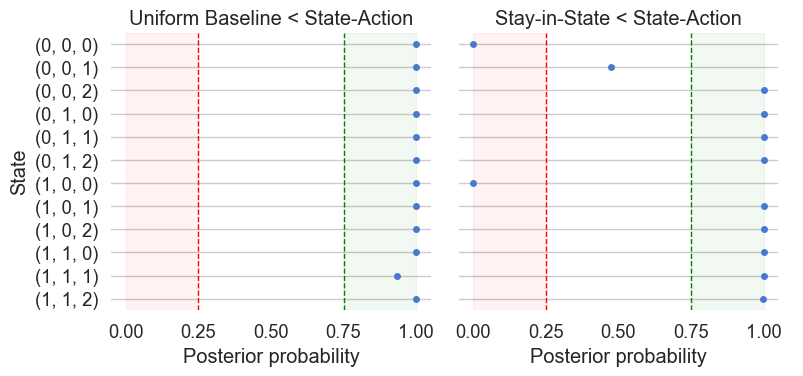

In [ ]:
df1 = results_transition_df_uniform.copy()
df2 = results_transition_df.copy()

df1['Comparison'] = 'Uniform Baseline < State-Action'
df2['Comparison'] = 'Stay-in-State < State-Action'

df = pd.concat([df1, df2, df3], ignore_index=True)
df["objective"] = df["objective"].apply(lambda x: str(x))

sns.set_context("notebook", font_scale=1.2)
ba.plot_post_prob(df, num_comparisons=2, y_label="State", save_path=results_folder + "figures/transition_model_comparison_bayesian.svg")